In [1]:
import math
import torch
import random
import numpy as np
from graphviz import Digraph
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape="record",
        )
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

- create the base data structure
- add a mechanism to track the relation with produced values (child nodes)
- add a similar mechanism to track which operation produced the parent node
- add the `draw_dot` function to visualize produced values trace
- add a `label` property to help with visualization
- _at this point we have some kind of forward pass structure_
- add the gradient variable and implement the backpropagation logic (establish the gradients related to L)
- $dL/dd = f \longrightarrow (L = d * f)$
- $dL/df = d \longrightarrow (L = d * f)$
- Applying the chain rule: $dz/dx = dz/dy \times dy/dx$
- $dL/dc = dL/dd \times dd/dc$
- $dL/de = dL/dd \times dd/de$
- For the sum operator (+) the chain rule just routes the gradients backwards
- $dL/da = dL/de \times de/da$
- $dL/db = dL/de \times de/db$
- For the product operator (*), the chain rule multiplies the gradient to the other variable value
- add the `tanh` operation
- we are more interested in the gradients related to $w_{1}$ and $w_{2}$ values 
- add the backward pass
- fix bug (+=): when using multiple variables (values)

In [3]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other)
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supports 'int' and 'float' powers."
        x = self.data
        out = Value(x**other, (self, ), f"**{other}")

        def _backward():
            self.grad += (other*(x**(other-1))) * out.grad # chain rule

        out._backward = _backward
        
        return out

    def backward(self):
        topo = []
        visited = set()
        
        def build_topo_order(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo_order(child)
                topo.append(v)

        build_topo_order(self)

        self.grad =1.0
        for node in reversed(topo):
            node._backward()
        

## Single Neuron Logic

In [4]:
# Neuron
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias of the neuron
b = Value(6.8813735870195432, label="b")

# forward pass compute
x1w1 = x1 * w1
x1w1.label = "x1*w1"
x2w2 = x2 * w2
x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"

n = x1w1x2w2 + b
n.label = "n"

# -------------
# o = n.tanh()
e = (2*n).exp()
o = (e - 1) / (e + 1)
# -------------
o.label = "o"

In [5]:
o.backward()

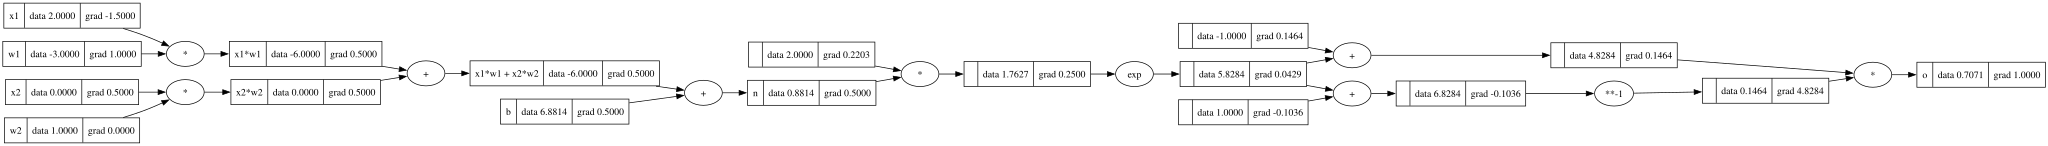

In [6]:
draw_dot(o)

## Pytorch Comparison

In [7]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

o.backward()

print(o.data.item())
print("-" * 25)
print("Gradients:")
print(f"x1: {x1.grad.item()}")
print(f"x2: {x2.grad.item()}")
print(f"w1: {w1.grad.item()}")
print(f"w2: {w2.grad.item()}")

0.7071066904050358
-------------------------
Gradients:
x1: -1.5000003851533106
x2: 0.5000001283844369
w1: 1.0000002567688737
w2: 0.0


## Neural Network

In [70]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params

class MLP:
    def __init__(self, nin, nouts):
        size = [nin] + nouts
        self.layers = [Layer(size[i], size[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [97]:
nn = MLP(3, [4, 4, 1])

In [98]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [92]:
y_pred = [nn(x) for x in xs]
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, y_pred)), Value(0.0))

In [101]:
for k in range(20):
    # forward pass
    y_pred = [nn(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, y_pred)), Value(0.0))

    # backward pass
    for p in nn.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in nn.parameters():
        p.data += -0.05 * p.grad

    print(f"Step {k} - Loss: {loss.data} - Y_pred: {[x.data for x in y_pred]}")

Step 0 - Loss: 0.05127669347781335 - Y_pred: [0.8973540888287231, -0.871954150539022, -0.9010654356758608, 0.8793487554335181]
Step 1 - Loss: 0.04719502375432831 - Y_pred: [0.9017553844247351, -0.8768040954232049, -0.9053312008684147, 0.8842260528819826]
Step 2 - Loss: 0.04367541293411442 - Y_pred: [0.905692680596705, -0.8811810789158089, -0.9091468461579447, 0.8886029135460899]
Step 3 - Loss: 0.04061257881678316 - Y_pred: [0.909239002308256, -0.8851555068737091, -0.9125832334014029, 0.8925566594395253]
Step 4 - Loss: 0.03792553148883132 - Y_pred: [0.9124525861290921, -0.8887841226350083, -0.9156968776234208, 0.896149174327587]
Step 5 - Loss: 0.03555103271970443 - Y_pred: [0.9153804646806694, -0.8921132081744841, -0.9185334215038581, 0.8994306025683024]
Step 6 - Loss: 0.03343904188813922 - Y_pred: [0.9180610546810103, -0.8951809195461962, -0.9211301454654919, 0.9024420298147027]
Step 7 - Loss: 0.03154948332407037 - Y_pred: [0.9205260574800023, -0.8980190190005595, -0.9235178116856164, 